# Experiment 3: normalized category profiles

One DAMICORE object represents one eligible source category. The input documents
are fixed-width relative-context profiles created by `00_create_artifacts`.


In [3]:
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import SVG, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or one of its subdirectories.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hypotheses.violence_against_women.scripts.experiment_common import (
    artifact_paths,
    case_execution,
    category_order_from_manifest,
    ensure_artifact_directories,
    load_artifact_manifest,
    load_category_map,
    run_damicore_experiment,
    write_common_result_artifacts,
)

CATEGORY_SET_VERSION = os.getenv("DAMICORE_CATEGORY_SET_VERSION", "v2_30")
PATHS = artifact_paths(CATEGORY_SET_VERSION)
COMMON_WORK_ROOT = PATHS.common
NORMALIZED_WORK_ROOT = PATHS.normalized
CASE_FULL_WORK_ROOT = PATHS.case_full
CASE_BALANCED_WORK_ROOT = PATHS.case_balanced
RESULTS_ROOT = PATHS.results
ensure_artifact_directories(PATHS)
manifest = load_artifact_manifest(
    COMMON_WORK_ROOT / "artifact-manifest.json",
    category_set_version=CATEGORY_SET_VERSION,
)
category_order = category_order_from_manifest(manifest)
category_map = load_category_map(COMMON_WORK_ROOT / "category-map.csv")
category_support = pd.read_csv(COMMON_WORK_ROOT / "category-support.csv")
assert category_map["category"].tolist() == category_order
assert set(category_support["category"]) == set(category_order)
assert manifest["dimension_count"] == 20


## Run DAMICORE and record the common result contract


distance: 100%|██████████| 435/435 [00:00<00:00, 1380.66pair/s]
/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,experiment,object_id,label,category,cluster
29,normalized_categories,file_000030,category-030.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,7
11,normalized_categories,file_000012,category-012.txt,INTEGRIDADE > FÍSICA > AGRESSÃO ou VIAS DE FATO,4
12,normalized_categories,file_000013,category-013.txt,INTEGRIDADE > FÍSICA > LESÃO CORPORAL,4
13,normalized_categories,file_000014,category-014.txt,INTEGRIDADE > FÍSICA > MAUS TRATOS,5
14,normalized_categories,file_000015,category-015.txt,INTEGRIDADE > FÍSICA > TORTURA FÍSICA,6
15,normalized_categories,file_000016,category-016.txt,INTEGRIDADE > FÍSICA > VIOLÊNCIA OBSTÉTRICA,3
22,normalized_categories,file_000023,category-023.txt,INTEGRIDADE > PATRIMONIAL > INDIVIDUAL,5
19,normalized_categories,file_000020,category-020.txt,INTEGRIDADE > PSÍQUICA > ALIENAÇÃO PARENTAL,7
16,normalized_categories,file_000017,category-017.txt,INTEGRIDADE > PSÍQUICA > AMEAÇA ou COAÇÃO,4
17,normalized_categories,file_000018,category-018.txt,INTEGRIDADE > PSÍQUICA > ASSÉDIO MORAL,6


,LIBERDADE > SEXUAL > FÍSICA > ESTUPRO,LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL,LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL > PEDOFILIA,LIBERDADE > SEXUAL > ESTUPRO VIRTUAL,LIBERDADE > SEXUAL > ESTUPRO CORRETIVO,LIBERDADE > SEXUAL > FÍSICA > ABUSO SEXUAL FÍSICO,LIBERDADE > SEXUAL > FÍSICA > EXPLORAÇÃO SEXUAL,LIBERDADE > SEXUAL > IMPORTUNAÇÃO SEXUAL,LIBERDADE > SEXUAL > PSÍQUICA > ABUSO SEXUAL PSÍQUICO,LIBERDADE > SEXUAL > PSÍQUICA > ASSÉDIO SEXUAL,...,INTEGRIDADE > PSÍQUICA > CONSTRANGIMENTO,INTEGRIDADE > PSÍQUICA > EXPOSIÇÃO (EROTIZAÇÃO),INTEGRIDADE > PATRIMONIAL > INDIVIDUAL,LIBERDADE > DIREITOS INDIVIDUAIS > CÁRCERE PRIVADO,LIBERDADE > DIREITOS INDIVIDUAIS > SEQUESTRO,LIBERDADE > DIREITOS INDIVIDUAIS > STALKING,LIBERDADE > DIREITOS INDIVIDUAIS > TRÁFICO DE MULHERES - INTERNACIONAL,LIBERDADE > DIREITOS INDIVIDUAIS > TRÁFICO DE MULHERES - NACIONAL,VIDA > FEMINICÍDIO,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES
LIBERDADE > SEXUAL > FÍSICA > ESTUPRO,0.000,0.562,0.569,0.572,0.571,0.552,0.537,0.560,0.547,0.536,...,0.571,0.539,0.563,0.545,0.563,0.564,0.627,0.626,0.582,0.612
LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL,0.562,0.000,0.351,0.365,0.365,0.408,0.513,0.355,0.397,0.527,...,0.571,0.512,0.560,0.531,0.464,0.403,0.578,0.578,0.393,0.563
LIBERDADE > SEXUAL > ESTUPRO DE VULNERÁVEL > PEDOFILIA,0.569,0.351,0.000,0.343,0.344,0.409,0.504,0.358,0.401,0.529,...,0.576,0.518,0.562,0.531,0.471,0.404,0.567,0.566,0.370,0.551
LIBERDADE > SEXUAL > ESTUPRO VIRTUAL,0.572,0.365,0.343,0.000,0.325,0.410,0.510,0.358,0.400,0.525,...,0.578,0.517,0.561,0.527,0.459,0.393,0.565,0.565,0.355,0.549
LIBERDADE > SEXUAL > ESTUPRO CORRETIVO,0.571,0.365,0.344,0.325,0.000,0.413,0.510,0.360,0.403,0.531,...,0.574,0.521,0.560,0.527,0.452,0.392,0.564,0.562,0.344,0.548
LIBERDADE > SEXUAL > FÍSICA > ABUSO SEXUAL FÍSICO,0.552,0.408,0.409,0.410,0.413,0.000,0.520,0.418,0.406,0.533,...,0.571,0.522,0.556,0.528,0.488,0.422,0.597,0.596,0.438,0.578
LIBERDADE > SEXUAL > FÍSICA > EXPLORAÇÃO SEXUAL,0.537,0.513,0.504,0.510,0.510,0.520,0.000,0.538,0.526,0.519,...,0.567,0.521,0.557,0.535,0.532,0.539,0.622,0.619,0.550,0.607
LIBERDADE > SEXUAL > IMPORTUNAÇÃO SEXUAL,0.560,0.355,0.358,0.358,0.360,0.418,0.538,0.000,0.396,0.518,...,0.576,0.518,0.559,0.528,0.471,0.403,0.579,0.578,0.396,0.557
LIBERDADE > SEXUAL > PSÍQUICA > ABUSO SEXUAL PSÍQUICO,0.547,0.397,0.401,0.400,0.403,0.406,0.526,0.396,0.000,0.522,...,0.569,0.515,0.556,0.531,0.484,0.420,0.595,0.592,0.437,0.576
LIBERDADE > SEXUAL > PSÍQUICA > ASSÉDIO SEXUAL,0.536,0.527,0.529,0.525,0.531,0.533,0.519,0.518,0.522,0.000,...,0.568,0.534,0.560,0.537,0.549,0.547,0.622,0.622,0.565,0.605


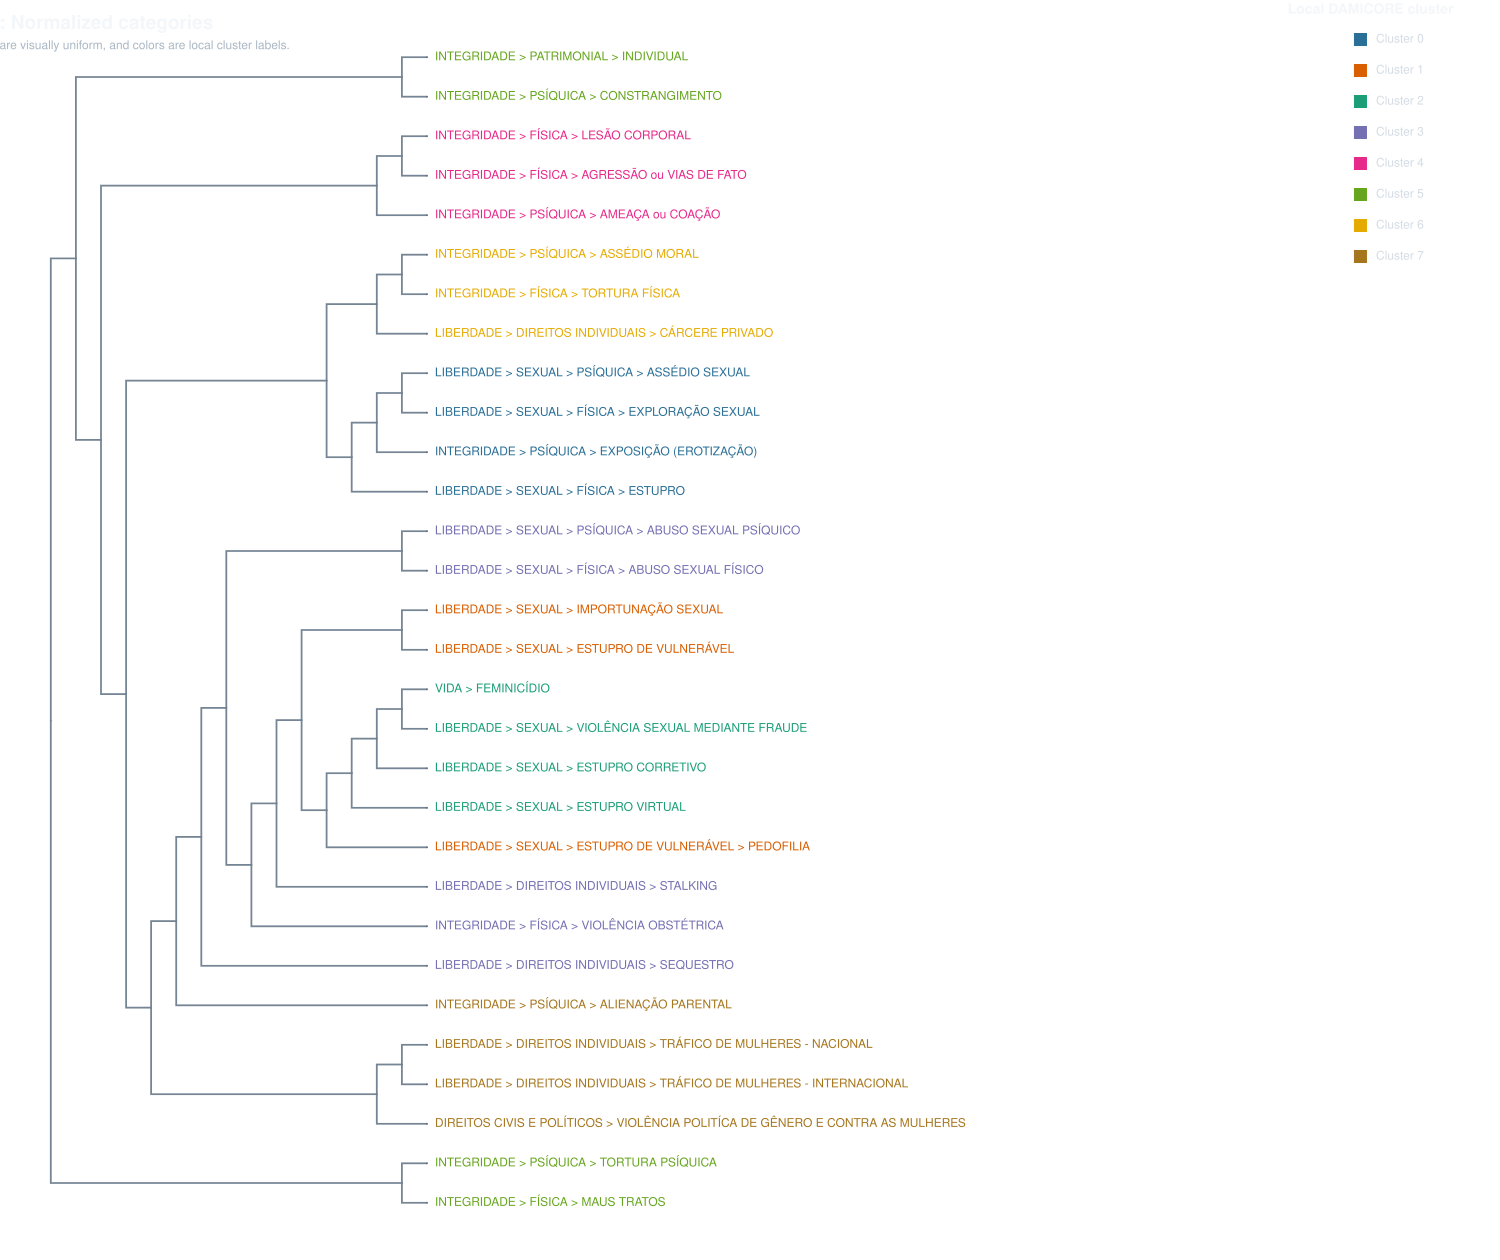

In [4]:
result = run_damicore_experiment(
    experiment_name="normalized_categories",
    corpus_dir=NORMALIZED_WORK_ROOT / "corpus",
    raw_runs_dir=NORMALIZED_WORK_ROOT / "runs",
    execution=case_execution(),
)
assert result["status"] == "completed", result["preview"]

bytes_by_category = {
    row.category: int((NORMALIZED_WORK_ROOT / "corpus" / row.label).stat().st_size)
    for row in category_map.itertuples(index=False)
}
output_dir = RESULTS_ROOT / "normalized_categories"
normalized_result = write_common_result_artifacts(
    result=result,
    category_map=category_map,
    category_order=category_order,
    support=category_support,
    bytes_by_category=bytes_by_category,
    output_dir=output_dir,
    support_column="support",
    support_label="Distinct reports (log scale)",
    title_prefix="Normalized categories",
    manifest=manifest,
)
display(normalized_result["membership_by_category"])
display(normalized_result["distance"].round(3))
display(SVG(filename=str(output_dir / "tree.svg")))


## Interpretation boundary

These clusters describe similarity among normalized contextual profiles. They are
exploratory and are not legal categories, causal mechanisms, or individual-level
predictions.
